<img src="imgs/unifor_logo.png" width="400">
<br>
<b>
<font size="6" face="arial" color="blue">
    Graduação em Ciência da Computação
</font>
</b>
<br>
<b>
<font size="4" face="arial">
    Disciplina: Métodos Quantitativos para Computação
</font>
</b>

**Orientador: Prof. Me. Ricardo Carubbi** <br>
*Docente da Graduação e Pós-Graduação em Ciência de Dados e Inteligência Artificial*<br>
*Laboratório de Ciência de Dados e Inteligência Artificial*<br>
*Universidade de Fortaleza*<br>

<p dir="ltr" style="text-align: left;">
    <strong>Links:</strong>
    <a href="https://www2.unifor.br/controle_pesquisa/pesquisarprofessor.do?actionParameter=prepareUpdate&amp;p_tp_ambiente=2&amp;p_tp_chamada=1&amp;p_tp_apresentacao=1&amp;cdPesquisador=767686193" target="_blank">Unifor</a> |
    <a href="http://lattes.cnpq.br/5738786447903616" target="_blank">Lattes</a> |
    <a href="https://unifor.br/web/pesquisa-inovacao/ncdia" target="_blank">NCDIA</a> |
    <a href="https://github.com/carubbi/" target="_blank">Github</a>
</p>

# **Medidas de Associação - Conceitos e Aplicações**

## **Configurações Iniciais**

In [245]:
# Bibliotecas para manipulação de dados, estatística e gráficos
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
from matplotlib.patches import Patch

In [246]:
# Ajustes visuais padrão para manter os gráficos legíveis
plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman", "DejaVu Serif", "STIXGeneral"],
    'figure.figsize': (7, 4.5),
    "font.size": 10,
    "axes.titlesize": 14,
    "axes.labelsize": 10,
    "legend.fontsize": 10,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
})


## **Conjunto de Dados**

In [247]:
# Leitura do arquivo CSV para o DataFrame principal
df = pd.read_csv('../../dataset/api.csv')
# Primeiras linhas para inspeção inicial dos dados
df.head()


,ID,TIPO,NOME,API00,API99,META,EDU,TEST_INSC,TEST_NUM,REFS,NPI
0,1611190130229,Superior,Alameda High,731,693,5,3.45,1278,1090,14,16
1,1611190132878,Superior,Encinal High,622,589,11,3.06,1113,840,20,18
2,1611196000004,Medio,Chipman Middle,622,572,11,2.82,546,472,55,25
3,1611196090005,Fundamental,Lum (Donald D.),774,732,3,3.32,330,272,35,26
4,1611196090013,Fundamental,Edison Elementa,811,784,1,3.76,233,216,15,9


In [248]:
# Estrutura do DataFrame: tipos, nulos e volume de dados
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5423 entries, 0 to 5422
Data columns (total 11 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   ID         5423 non-null   int64  
 1   TIPO       5423 non-null   object 
 2   NOME       5423 non-null   object 
 3   API00      5423 non-null   int64  
 4   API99      5423 non-null   int64  
 5   META       5423 non-null   int64  
 6   EDU        5423 non-null   float64
 7   TEST_INSC  5423 non-null   int64  
 8   TEST_NUM   5423 non-null   int64  
 9   REFS       5423 non-null   int64  
 10  NPI        5423 non-null   int64  
dtypes: float64(1), int64(8), object(2)
memory usage: 466.2+ KB


## **Medidas de Associação**

Nas seções anteriores, concentramos nossa atenção principalmente em uma única variável, descrevendo sua distribuição e calculando estatísticas-resumo. Estatísticas que descrevem uma única variável são chamadas de [estatísticas univariadas](https://userpage.fu-berlin.de/soga/soga-py/200/2020_descriptive_statistics/20220_measures_of_dispersion.html). Quando examinamos a relação entre duas variáveis, tratamos de [estatísticas bivariadas](https://www.geo.fu-berlin.de/en/v/soga-py/Basics-of-statistics/Descriptive-Statistics/Measures-of-Relation-Between-Variables/index.html). Quando as relações entre várias variáveis são examinadas simultaneamente, tratamos de estatísticas multivariadas. As [medidas de associação](https://userpage.fu-berlin.de/soga/soga-r/200/2020_descriptive_statistics/20242_correlation.html) fornecem uma forma de resumir a relação entre duas variáveis.

### **Covariância**

A **covariância** é uma medida de associação que descreve a **variação conjunta** de duas variáveis quantitativas. Ela indica se valores **acima da média** de uma variável tendem a ocorrer junto com valores **acima da média** da outra, ou se ocorre o padrão oposto.

Para uma amostra com pares de observações $(x_1, y_1), (x_2, y_2), \ldots, (x_n, y_n)$, a **covariância amostral** pode ser escrita como

$$
s_{xy} = \frac{\sum_{i=1}^{n}(x_i-\bar{x})(y_i-\bar{y})}{n-1} \tag{1}
$$

Nessa expressão:

- $\bar{x}$ é a média amostral da variável $X$;
- $\bar{y}$ é a média amostral da variável $Y$;
- $(x_i-\bar{x})(y_i-\bar{y})$ mede a contribuição conjunta do par de observações em relação às médias.

A interpretação do sinal da covariância é direta:

- se **$s_{xy} > 0$**, as variáveis tendem a variar **na mesma direção**;
- se **$s_{xy} < 0$**, as variáveis tendem a variar **em direções opostas**;
- se **$s_{xy} \approx 0$**, não há evidência de associação linear sistemática relevante com base nessa medida isoladamente.

Apesar de útil, a covariância tem uma **limitação importante**: seu valor depende das **unidades de medida** das variáveis. Por isso, sua magnitude isolada não é adequada para comparar a intensidade da associação entre pares de variáveis em escalas diferentes. Essa é precisamente a motivação para introduzir, em seguida, medidas **padronizadas** de associação, como o **coeficiente de correlação**.

#### **Exemplo Didático 1**

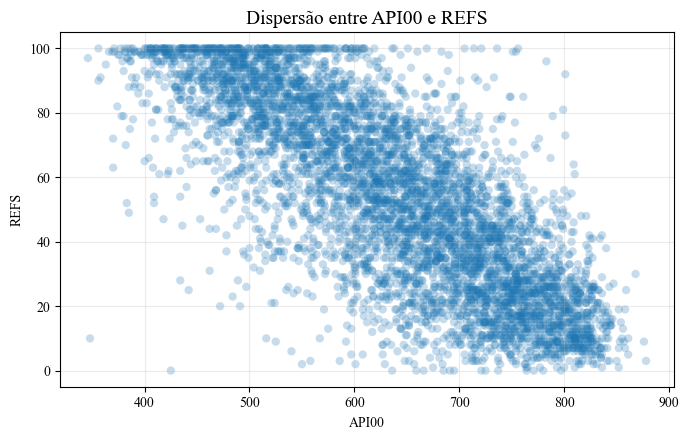

In [249]:
# Grafico de dispersão entre API00 e REFS para visualizar a relação entre as duas variáveis
fig, ax = plt.subplots()
ax.scatter(df["API00"], df["REFS"], alpha=0.25, edgecolors="none")
ax.set_title("Dispersão entre API00 e REFS")
ax.set_xlabel("API00")
ax.set_ylabel("REFS")
ax.grid(alpha=0.25)
fig.tight_layout()
plt.show()


**Fig. 1 – Gráfico de dispersão entre $API00$ e $REFS$**. A figura apresenta a relação entre as variáveis **$API00$** e **$REFS$** por meio de um **gráfico de dispersão**. Cada ponto representa uma escola do conjunto de dados, permitindo visualizar o comportamento conjunto das duas variáveis e identificar, de forma exploratória, a direção geral da associação. Neste caso, a distribuição dos pontos sugere uma **associação negativa**, coerente com o sinal da covariância calculada. Fonte: Carubbi, 2026.

In [250]:
# Função manual para calcular a covariância amostral conforme a Equação (1)
def covariancia_manual(x: list[float], y: list[float]) -> float:
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    if len(x) != len(y):
        raise ValueError('As listas x e y devem ter o mesmo comprimento.')

    mascara = ~np.isnan(x) & ~np.isnan(y)
    x = x[mascara]
    y = y[mascara]

    if len(x) < 2:
        raise ValueError('São necessários pelo menos dois pares válidos para calcular a covariância.')
    
    desvios_x = x - np.mean(x)
    desvios_y = y - np.mean(y)
    soma_produtos = np.sum(desvios_x * desvios_y)

    return soma_produtos / (len(x) - 1)


In [251]:
# Cálculo da covariância manual entre API00 e REFS
api00 = df['API00']
refs = df['REFS']
covariancia_manual(api00, refs)

np.float64(-2436.7701758422954)

No exemplo acima, a covariância entre **$API00$** e **$REFS$** indica como essas duas variáveis variam conjuntamente no conjunto de dados. Como o valor calculado é **negativo**, valores mais altos de **$API00$** tendem, em média, a estar associados a valores menores de **$REFS$**. O **gráfico de dispersão** ajuda a inspecionar visualmente esse padrão. Ainda assim, a **magnitude** da covariância deve ser interpretada com cautela, pois ela depende da **escala de medida** das variáveis. Por isso, na sequência, é mais apropriado utilizar uma medida **padronizada**, como o **coeficiente de correlação**.

### **Correlação**

A [**correlação**](https://www.geo.fu-berlin.de/en/v/soga-py/Basics-of-statistics/Descriptive-Statistics/Measures-of-Relation-Between-Variables/Correlation/index.html) é **uma medida amplamente utilizada para examinar a relação entre variáveis quantitativas**. A estatística mais comum nesse contexto é o **coeficiente de correlação linear** $r$, também conhecido como **coeficiente de correlação produto-momento de Pearson**, em homenagem ao seu desenvolvedor, **Karl Pearson**. Diferentemente da [covariância](https://www.geo.fu-berlin.de/en/v/soga-py/Basics-of-statistics/Descriptive-Statistics/Measures-of-Relation-Between-Variables/Covariance/index.html), essa medida é **independente da escala**, pois divide a covariância pelos desvios-padrão das duas variáveis.

$$
r = \frac{\sum_{i=1}^{n}(x_i-\bar{x})(y_i-\bar{y})}{\sqrt{\sum_{i=1}^{n}(x_i-\bar{x})^2}\sqrt{\sum_{i=1}^{n}(y_i-\bar{y})^2}} = \frac{s_{xy}}{s_x s_y} \tag{2}
$$

Nessa expressão:

- $r$ é o **coeficiente de correlação linear de Pearson**;
- $s_{xy}$ é a **covariância amostral** entre $X$ e $Y$;
- $s_x$ é o **desvio-padrão amostral** da variável $X$;
- $s_y$ é o **desvio-padrão amostral** da variável $Y$;
- $\bar{x}$ e $\bar{y}$ são as **médias amostrais** de $X$ e $Y$, respectivamente.

Como consequência, o coeficiente $r$ assume valores entre **-1** e **1**.

- Considerando o **valor absoluto** de $r$, valores **abaixo de 0,3** indicam associação **fraca ou insignificante**.
- Considerando o **valor absoluto** de $r$, valores **entre 0,3 e 0,7** indicam associação **média**.
- Considerando o **valor absoluto** de $r$, valores **acima de 0,7** indicam associação **forte**.
- O **sinal** de $r$ indica **a direção da relação**: valores positivos sugerem associação linear positiva, enquanto valores negativos indicam associação linear negativa.

Essa classificação funciona como uma **regra prática de interpretação**, conforme [Barbetta](https://www.amazon.com.br/Estat%C3%ADstica-para-cursos-engenharia-inform%C3%A1tica/dp/8522449899), e não como um critério absoluto aplicável a todo contexto.

Embora seja muito útil, o coeficiente de Pearson pressupõe, em geral, que as variáveis tenham distribuição aproximadamente normal e **não é robusto à presença de outliers**. Por isso, sua interpretação deve sempre ser acompanhada de **inspeção gráfica**, como no gráfico de dispersão.

#### **Exemplo Didático 2**

Vamos calcular o **coeficiente de correlação de Pearson** entre **$API00$** e **$REFS$** de três formas: manualmente pela Equação (2), pela razão entre a covariância e os desvios-padrão, e por meio de uma função pronta da biblioteca.

In [252]:
# Função manual para calcular a correlação de Pearson conforme a Equação (2)
def correlacao_pearson_manual(x: list[float], y: list[float]) -> float:
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    if len(x) != len(y):
        raise ValueError('As listas x e y devem ter o mesmo comprimento.')

    mascara = ~np.isnan(x) & ~np.isnan(y)
    x = x[mascara]
    y = y[mascara]

    if len(x) < 2:
        raise ValueError('São necessários pelo menos dois pares válidos para calcular a correlação.')

    desvios_x = x - np.mean(x)
    desvios_y = y - np.mean(y)

    soma_produtos = np.sum(desvios_x * desvios_y)
    raiz_somas_quadrados = np.sqrt(
        np.sum(desvios_x ** 2) * np.sum(desvios_y ** 2)
    )

    if raiz_somas_quadrados == 0:
        raise ValueError('A correlação é indefinida quando uma das variáveis tem variância nula.')

    return soma_produtos / raiz_somas_quadrados


In [253]:
# Cálculo da correlação de Pearson entre API00 e REFS por três abordagens
api00 = df['API00']
refs = df['REFS']

r_manual = correlacao_pearson_manual(api00, refs)

dados = df[['API00', 'REFS']].dropna()
r_via_cov = dados['API00'].cov(dados['REFS']) / (dados['API00'].std() * dados['REFS'].std())
r_pandas = dados['API00'].corr(dados['REFS'])

pd.DataFrame({
    'Método': ['Cálculo manual', 'Covariância / desvios-padrão', 'pandas.corr()'],
    'Coeficiente de correlação (r)': [r_manual, r_via_cov, r_pandas],
})


,Método,Coeficiente de correlação (r)
0,Cálculo manual,-0.775857
1,Covariância / desvios-padrão,-0.775857
2,pandas.corr(),-0.775857


Os três procedimentos devem produzir o mesmo resultado. Isso reforça que o coeficiente de Pearson pode ser entendido tanto pela sua **fórmula explícita** quanto pela relação $r = \frac{s_{xy}}{s_x s_y}$.

#### **Exemplo Didático 3**

A seguir, calculamos uma **matriz de correlação** para algumas variáveis numéricas do conjunto de dados, o que permite comparar várias associações lineares ao mesmo tempo.

In [254]:
# Matriz de correlação para um subconjunto de variáveis numéricas
vars_corr = ['API00', 'API99', 'META', 'EDU', 'TEST_INSC', 'TEST_NUM', 'REFS', 'NPI']
mat_corr = df[vars_corr].corr()
mat_corr


,API00,API99,META,EDU,TEST_INSC,TEST_NUM,REFS,NPI
API00,1.000000,0.963544,-0.962322,0.734711,-0.185540,-0.178289,-0.775857,-0.681180
API99,0.963544,1.000000,-0.998592,0.762214,-0.104658,-0.101859,-0.813196,-0.708296
META,-0.962322,-0.998592,1.000000,-0.761254,0.104851,0.102134,0.812160,0.708310
EDU,0.734711,0.762214,-0.761254,1.000000,0.044753,0.040159,-0.773485,-0.664399
TEST_INSC,-0.185540,-0.104658,0.104851,0.044753,1.000000,0.970962,-0.108994,-0.008540
TEST_NUM,-0.178289,-0.101859,0.102134,0.040159,0.970962,1.000000,-0.077427,0.015412
REFS,-0.775857,-0.813196,0.812160,-0.773485,-0.108994,-0.077427,1.000000,0.748597
NPI,-0.681180,-0.708296,0.708310,-0.664399,-0.008540,0.015412,0.748597,1.000000


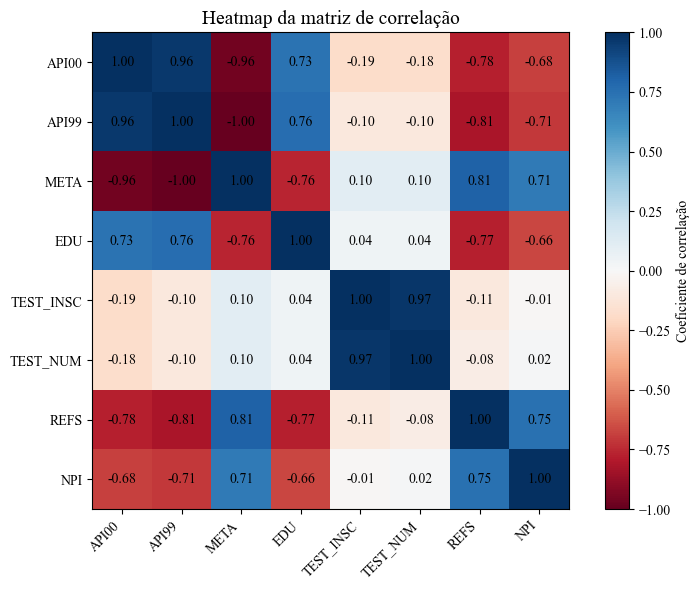

In [255]:
# Ajustes visuais padrão para manter os gráficos legíveis
fig, ax = plt.subplots(figsize=(8, 6))
img = ax.imshow(mat_corr, cmap='RdBu', vmin=-1, vmax=1)
fig.colorbar(img, ax=ax, label='Coeficiente de correlação')
ax.set_xticks(range(len(mat_corr.columns)))
ax.set_xticklabels(mat_corr.columns, rotation=45, ha='right')
ax.set_yticks(range(len(mat_corr.index)))
ax.set_yticklabels(mat_corr.index)

for i in range(len(mat_corr.index)):
    for j in range(len(mat_corr.columns)):
        ax.text(j, i, f'{mat_corr.iloc[i, j]:.2f}', ha='center', va='center', color='black')

ax.set_title('Heatmap da matriz de correlação')
fig.tight_layout()
plt.show()


**Fig. 2 – Heatmap da matriz de correlação**. A figura apresenta os coeficientes de correlação de Pearson calculados **par a par** entre as variáveis numéricas selecionadas. Tons associados a valores próximos de **1** ou **-1** indicam associações lineares mais intensas, enquanto tons próximos de **0** sugerem associação linear fraca ou inexistente. Fonte: Carubbi, 2026.

A matriz de correlação resume os coeficientes de Pearson calculados **par a par**. Valores mais próximos de **1** ou **-1** indicam associações lineares mais intensas, enquanto valores próximos de **0** sugerem associação linear fraca ou inexistente.

Uma tabela é uma boa forma de representar uma análise de correlação, mas uma **figura** naturalmente melhora a **interpretabilidade**. O pacote **`seaborn`** fornece a função **`pairplot()`**, que facilita a visualização conjunta das relações entre as variáveis da matriz de correlação.

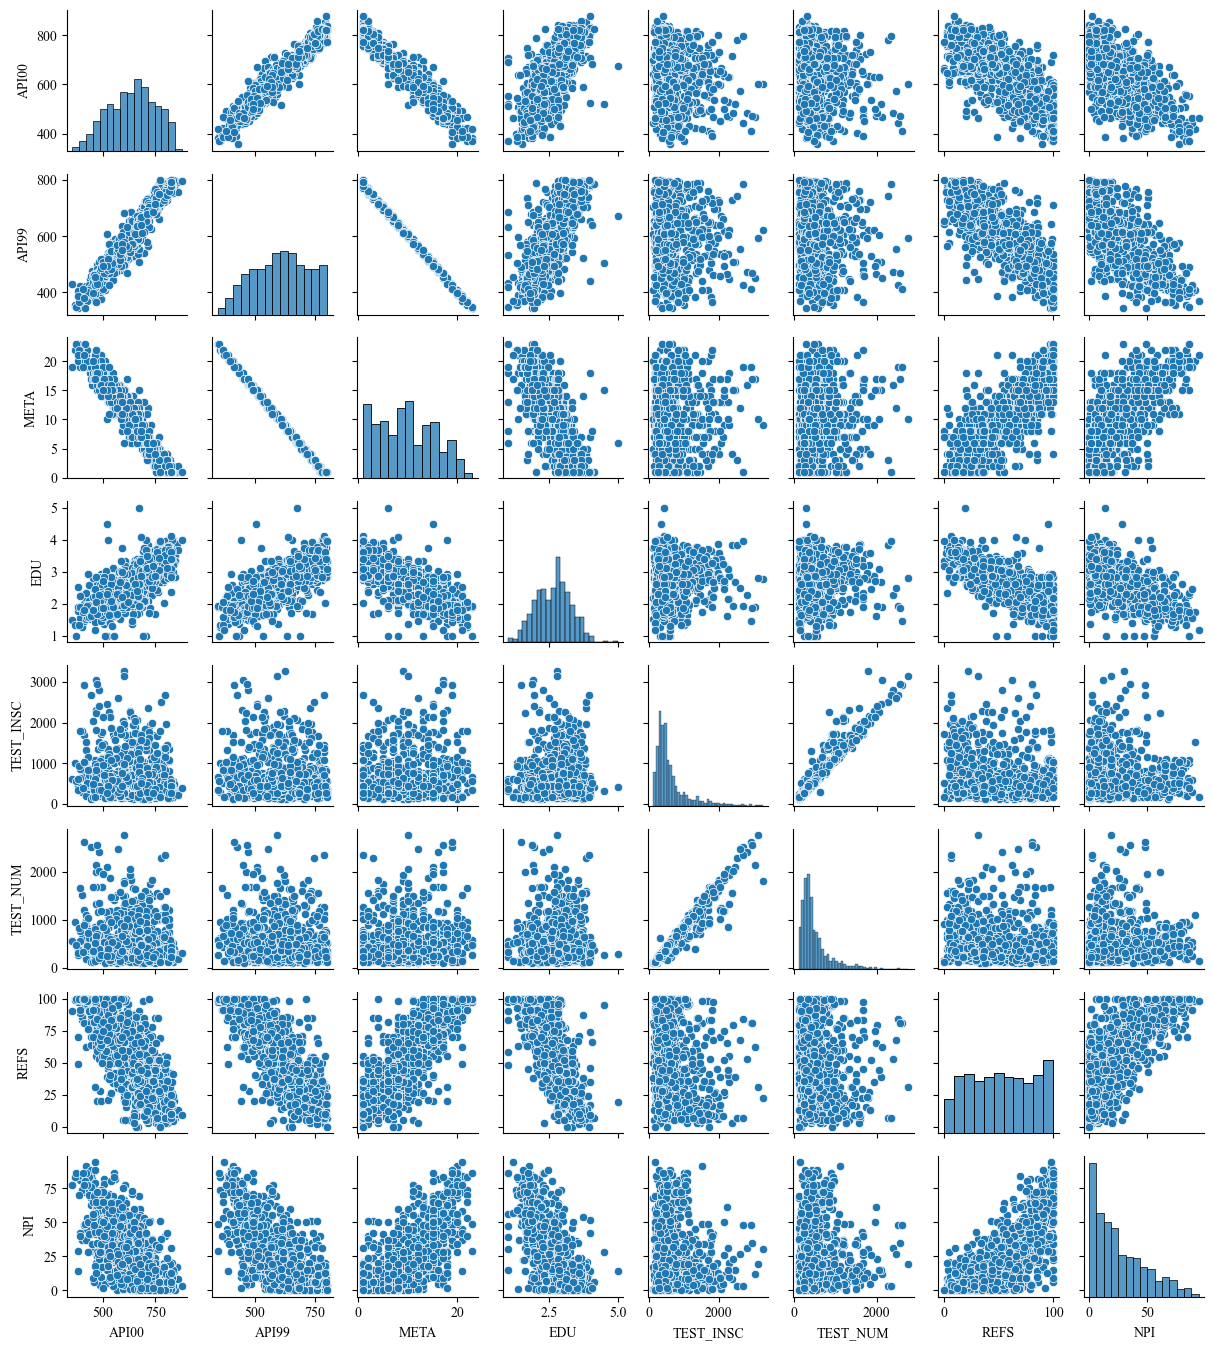

In [256]:
# Ajustes visuais padrão para manter os gráficos legíveis
dados_pp = df[vars_corr].dropna()
amostra_pp = dados_pp.sample(n=min(1000, len(dados_pp)), random_state=42)

g = sns.pairplot(amostra_pp, height=1.7, aspect=0.9)
g.figure.tight_layout()
plt.show()


**Fig. 3 – Pairplot da matriz de correlação**. A figura apresenta, de forma combinada, os gráficos de dispersão entre pares de variáveis e a distribuição de cada variável no subconjunto analisado. Essa visualização complementa a matriz de correlação ao permitir inspeção gráfica direta da direção, da intensidade e de possíveis padrões não lineares entre as variáveis. Fonte: Carubbi, 2026.

## **Citação**

Estas aulas são baseadas no projeto de ensino a distância [SOGA-Py](https://www.geo.fu-berlin.de/en/v/soga-py/index.html), desenvolvido no Departamento de Ciências da Terra por Annette Rudolph, Joachim Krois e Kai Hartmann. O contato pode ser realizado por e-mail, pelo endereço [soga[at]zedat.fu-berlin.de](soga[at]zedat.fu-berlin.de).

<p align="left">
  <a href="https://creativecommons.org/licenses/by-sa/4.0/" target="_blank" rel="noopener noreferrer">
    <img src="imgs/cc.png" width="75" alt="Licença Creative Commons BY-SA 4.0">
  </a>
</p>

Você pode utilizar este projeto livremente sob a Licença Creative Commons Atribuição-CompartilhaIgual 4.0 Internacional. 

Por favor, cite da seguinte forma: Rudolph, A., Krois, J., Hartmann, K. (2023): Estatística e Análise de Geodados usando Python (SOGA-Py). Departamento de Ciências da Terra, Universidade Livre de Berlim.